In [1]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.4 MB/s eta 0:00:00


SCRAPING DATA

In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np

apps = {
    "instagram": "com.instagram.android",
    "tiktok": "com.ss.android.ugc.trill"
}

for nama, app_id in apps.items():
    print(f"Scraping {nama}...")

    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=4000,
        filter_score_with=None
    )

    df = pd.DataFrame(np.array(result), columns=['review'])
    df = df.join(pd.DataFrame(df.pop('review').tolist()))

    df_final = df[['score', 'content']]
    df_final.to_csv(f"ulasan_{nama}.csv", index=False, encoding="utf-8-sig")

Scraping instagram...
Scraping tiktok...


PREPROCESSING

In [3]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [4]:
# ======================================
# IMPORT LIBRARY
# ======================================
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')

# ======================================
# FILE INPUT
# ======================================
files = [
    "ulasan_instagram.csv",
    "ulasan_tiktok.csv"
]

# ======================================
# CASE FOLDING & CLEANING
# ======================================
def clean_text(text):
    text = str(text).lower()                   # case folding
    text = re.sub(r'(.)\1{2,}', r'\1', text)   # huruf berulang
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # non ASCII
    text = re.sub(r'\d+', '', text)            # angka
    text = re.sub(r'[^\w\s]', '', text)        # tanda baca
    text = re.sub(r'\s+', ' ', text).strip()   # spasi berlebih
    return text

# ======================================
# NORMALISASI PER FILE
# ======================================
normalisasi_per_file = {
    "ulasan_instagram.csv": {
        "ngeleg":"lemot","ngelag":"lemot","lag":"lemot","leg":"lemot","lemott":"lemot","crash":"error","error":"eror","eror":"eror","forceclose":"tutup","close":"tutup",
        "hang":"macet","freeze":"macet","knp":"kenapa","kenp":"kenapa","ngapa":"kenapa","gmn":"bagaimana","gimana":"bagaimana","reels":"video","story":"cerita",
        "stories":"cerita","dm":"pesan","direct":"pesan","feed":"beranda","followers":"pengikut","follower":"pengikut","following":"ikuti",
        "apdet":"update","updet":"update","updte":"update","updatee":"update","mulu":"terus","trs":"terus","dowload":"unduh","download":"unduh",
        "donlod":"unduh","instal":"pasang","install":"pasang","login":"masuk","logout":"keluar","gk":"tidak","ga":"tidak","gak":"tidak","ngga":"tidak",
        "tdk":"tidak","tak":"tidak","bgt":"banget","bgtt":"banget","bnget":"banget","bangett":"banget","parahh":"parah","skrg":"sekarang","skrng":"sekarang",
        "dlu":"dulu","dl":"dulu","gue":"saya","gua":"saya","aku":"saya","sy":"saya","mantul":"mantap","mantappp":"mantap","keren":"bagus","baguss":"bagus",
        "parah":"buruk","jelek":"buruk","burukk":"buruk","kesel":"kesal","capek":"lelah","cape":"lelah","ribet":"rumit","good":"bagus","ok":"baik","okay":"baik",
        "apk":"aplikasi","app":"aplikasi","notif":"notifikasi","notip":"notifikasi","loginan":"masuk","loginnya":"masuk","bikin":"buat","buat":"buat","udah":"sudah",
        "hilang":"hapus","aneh":"buruk","bug":"masalah","errornya":"eror","iklan":"iklan","ads":"iklan","tolong":"minta","kasih":"beri","ganti":"ubah","perbaiki":"perbaiki",
        "sekali":"sangat","ni": "ini","tu": "itu","kalo": "kalau","kalau": "kalau","kl": "kalau","karna": "karena","krn": "karena","bisa": "bisa","bisanya": "bisa","gabisa": "tidak bisa",
        "ngak": "tidak","g": "tidak","ndak": "tidak","sdh": "sudah","udh": "sudah","jd": "jadi","jdi": "jadi","dapet": "dapat","dpt": "dapat","liat": "lihat","kelihatan": "terlihat",
        "ngetik": "ketik","balas": "balas","replei": "balas","balesan": "balasan","ilang": "hapus","kehapus": "hapus","balikin": "kembalikan","kyk": "seperti","kayak": "seperti","kek": "seperti",
        "macem": "macam","malah": "malah","emang": "memang","mang": "memang","bener": "benar","beneran": "benar","getol": "rajin","ngirim": "kirim","kiriman": "kirim","mending": "lebih baik",
        "balikan": "kembali","sm": "sama","sama": "sama","aja": "saja","sajah": "saja"
    },

    "ulasan_tiktok.csv": {
        "ngeleg":"lemot","ngelag":"lemot","lag":"lemot","lemott":"lemot","lelet":"lemot","crash":"error","error":"eror","eror":"eror","forceclose":"tutup","close":"tutup",
        "freeze":"macet","hang":"macet","stuck":"macet","bug":"masalah","fyp":"rekomendasi","foryou":"rekomendasi","foru":"rekomendasi",
        "live":"siaran","liv":"siaran","vt":"video","vid":"video","videoo":"video","komen":"komentar","koment":"komentar","comen":"komentar",
        "apdet":"update","updet":"update","updte":"update","updatee":"update","dowload":"unduh","download":"unduh","donlod":"unduh",
        "instal":"pasang","install":"pasang","login":"masuk","logout":"keluar","gk":"tidak","ga":"tidak","gak":"tidak","ngga":"tidak","tdk":"tidak","tak":"tidak",
        "bgt":"banget","bgtt":"banget","bnget":"banget","bangett":"banget","udh":"sudah","uda":"sudah","udah":"sudah","sdh":"sudah","blm":"belum","belom":"belum","aja":"saja","doang":"saja",
        "mantul":"mantap","mantappp":"mantap","keren":"bagus","baguss":"bagus","parah":"buruk","parahh":"buruk","jelek":"buruk","burukk":"buruk",
        "kocak":"lucu","ngakak":"lucu","seru":"menarik","asyik":"menarik","kesel":"kesal","capek":"lelah","cape":"lelah","ribet":"rumit",
        "knp":"kenapa","kenp":"kenapa","ngapa":"kenapa","gmn":"bagaimana","gimana":"bagaimana","skrg":"sekarang","skrng":"sekarang","dlu":"dulu","dl":"dulu",
        "gue":"saya","gua":"saya","aku":"saya","sy":"saya","sound":"audio","musik":"audio","lagu":"audio","filter":"efek","effect":"efek",
        "scroll":"gulir","geser":"gulir","iklan":"iklan","ads":"iklan","ok":"baik","oke":"baik","okay":"baik","good":"bagus","nice":"bagus",
        "apk":"aplikasi","app":"aplikasi","apps":"aplikasi","notif":"notifikasi","notip":"notifikasi","notifnya":"notifikasi",
        "akun":"akun","acc":"akun","loginan":"masuk","logoutnya":"keluar","bikin":"buat","dibikin":"buat","buat":"buat",
        "ilang":"hilang","ilangin":"hapus","aneh":"buruk","anehh":"buruk","tolong":"minta","pls":"minta","plis":"minta",
        "ganti":"ubah","diganti":"ubah","perbaiki":"perbaiki","diperbaiki":"perbaiki","sekali":"sangat","bangett":"banget",
        "lemotnya":"lemot","macetnya":"macet","errornya":"eror","updatean":"update","lama":"lambat","lambat":"lambat",
        "full":"penuh","jelek banget":"buruk","parah banget":"buruk","kalo": "kalau","klo": "kalau","kl": "kalau","karna": "karena","krn": "karena",
        "bisa": "bisa","bisanya": "bisa","gabisa": "tidak bisa","ngak": "tidak","g": "tidak","ndak": "tidak","kagak": "tidak","jd": "jadi",
        "jdi": "jadi","dapet": "dapat","dpt": "dapat","liat": "lihat","ngeliat": "lihat","kelihatan": "terlihat","ngetik": "ketik",
        "balas": "balas","replei": "balas","balesan": "balasan","kehapus": "hapus","balikin": "kembalikan","kyk": "seperti","kayak": "seperti",
        "kek": "seperti","macem": "macam","emang": "memang","mang": "memang","bener": "benar","beneran": "benar","mending": "lebih baik",
        "sm": "sama","sama": "sama","sajah": "saja","terimakasih": "terima kasih","makasih": "terima kasih","thx": "terima kasih","kualitas": "kualitas","burik": "buruk","hd": "jernih"
        }
}

def normalisasi_kata(text, normalisasi_dict):
    words = text.split()
    return ' '.join([normalisasi_dict.get(w, w) for w in words])

# ======================================
# STOPWORD
# ======================================
stop_factory = StopWordRemoverFactory()
stopwords_sastrawi = set(stop_factory.get_stop_words())

custom_stopwords_per_file = {
    "ulasan_instagram.csv": {
        "ig","instagram","reels","story","dm","ae","ajae","aetaek","nya","sih","deh","dong","lah","loh","kok","nih","yaa","yah","ya","wkwk","haha","hehe","hahaha",
        "pls","plis","min","admin","lah","pun","kok","kan","juga","lagi","itu","ini","aja","udah","dong","sih","yg","yang","nya","mau","tapi","padahal","dari","ke","di","buat","bikin",
        "tolong", "yg", "yang", "nya", "sih", "deh", "dong", "lah", "loh", "kok", "nih", "ya", "pun", "kan", "juga", "itu", "ini", "dari", "ke", "di", "dan", "atau", "oleh", "adalah", "bahwa"
    },

    "ulasan_tiktok.csv": {
        "tiktok","tt","fyp","foryou","foru","vt","vid","live","liv","nya","sih","deh","dong","lah","loh","kok","nih","ya","yah","yaa","aja","ae","wkwk","haha","hehe",
        "hahaha","wk","pls","plis","min","admin","dong","kan","kok","pun","yg","yang","itu","ini","sama","juga","lagi","masih","udah","belum","mau","bakal","pengen",
        "ingin","karena","soalnya","padahal","tapi","cuma","hanya","buat","bikin","jadi","di","ke","dari","aku","saya","gue","gua","nya","pun","kok","kan","lah","sih",
        "yg","yang","yg", "yang", "nya", "sih", "deh", "dong", "lah", "loh", "kok", "nih", "ya", "kan", "pun", "itu", "ini", "juga", "lagi", "masih", "karena", "padahal",
        "tapi", "cuma", "hanya", "di", "ke", "dari", "dan", "atau", "oleh", "adalah", "bahwa"
    }
}

def remove_stopwords_text(text, stopwords):
    return ' '.join([w for w in text.split() if w not in stopwords])

# ======================================
# STEMMING
# ======================================
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming_text(text):
    return stemmer.stem(text)

# ======================================
# PROSES PREPROCESSING
# ======================================
for file in files:
    print(f"Memproses file: {file}")

    df = pd.read_csv(file)

    #ambil kamus sesuai file
    normalisasi_dict = normalisasi_per_file.get(file, {})
    custom_stopwords = custom_stopwords_per_file.get(file, set())

    all_stopwords = stopwords_sastrawi.union(custom_stopwords)

    df['content_casefold'] = df['content'].astype(str).str.lower()
    df['cleaned'] = df['content_casefold'].apply(clean_text)
    df['normalized'] = df['cleaned'].apply(
        lambda x: normalisasi_kata(x, normalisasi_dict)
    )
    df['no_stopword'] = df['normalized'].apply(
        lambda x: remove_stopwords_text(x, all_stopwords)
    )
    df['stemmed'] = df['no_stopword'].apply(stemming_text)

    #simpan hasil
    output_file = file.replace(".csv", "_preprocessing.csv")
    df.to_csv(output_file, index=False)

    print(f"Berhasil disimpan: {output_file}\n")

print("=== PREPROCESSING SELESAI ===")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Memproses file: ulasan_instagram.csv
Berhasil disimpan: ulasan_instagram_preprocessing.csv

Memproses file: ulasan_tiktok.csv
Berhasil disimpan: ulasan_tiktok_preprocessing.csv

=== PREPROCESSING SELESAI ===


PELABELAN (RATING)

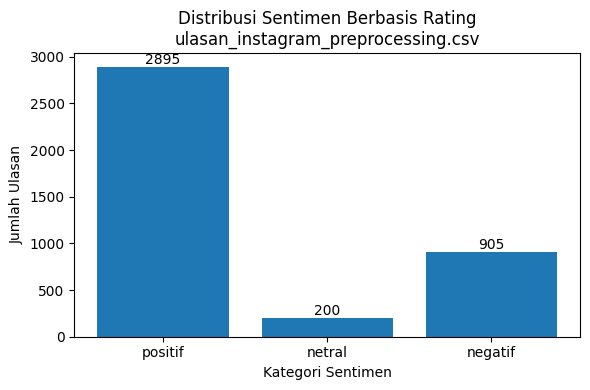

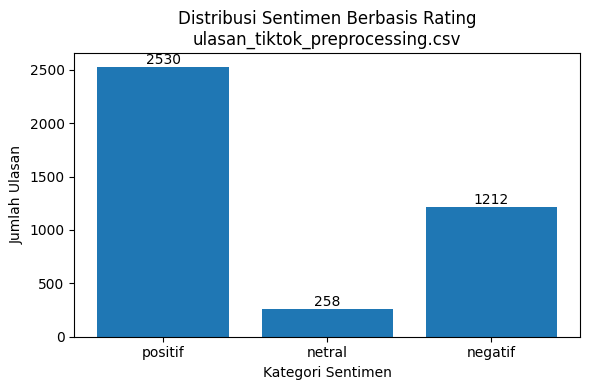

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

files = [
    "ulasan_instagram_preprocessing.csv",
    "ulasan_tiktok_preprocessing.csv"
]

def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

for file in files:
    # Baca data
    df = pd.read_csv(file)

    # Pastikan kolom score numerik
    df['score'] = pd.to_numeric(df['score'], errors='coerce')

    # Pelabelan sentimen
    df['sentiment'] = df['score'].apply(label_sentiment)

    # Simpan hasil pelabelan
    output_file = file.replace(".csv", "_labeled.csv")
    df.to_csv(output_file, index=False)

    # ==============================
    # Visualisasi Distribusi Sentimen
    # ==============================
    sentiment_count = df['sentiment'].value_counts().reindex(
        ['positif', 'netral', 'negatif'], fill_value=0
    )

    plt.figure(figsize=(6, 4))
    plt.bar(sentiment_count.index, sentiment_count.values)
    plt.title(f"Distribusi Sentimen Berbasis Rating\n{file}")
    plt.xlabel("Kategori Sentimen")
    plt.ylabel("Jumlah Ulasan")

    # Tampilkan angka di atas bar
    for i, v in enumerate(sentiment_count.values):
        plt.text(i, v + 1, str(v), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

--- ulasan_instagram_preprocessing_labeled.csv ---
Data Awal         : 4000
Data Dihapus      : 315
Data Valid (Tetap): 3685
Akurasi Awal      : 92.12%

--- ulasan_tiktok_preprocessing_labeled.csv ---
Data Awal         : 4000
Data Dihapus      : 542
Data Valid (Tetap): 3458
Akurasi Awal      : 86.45%



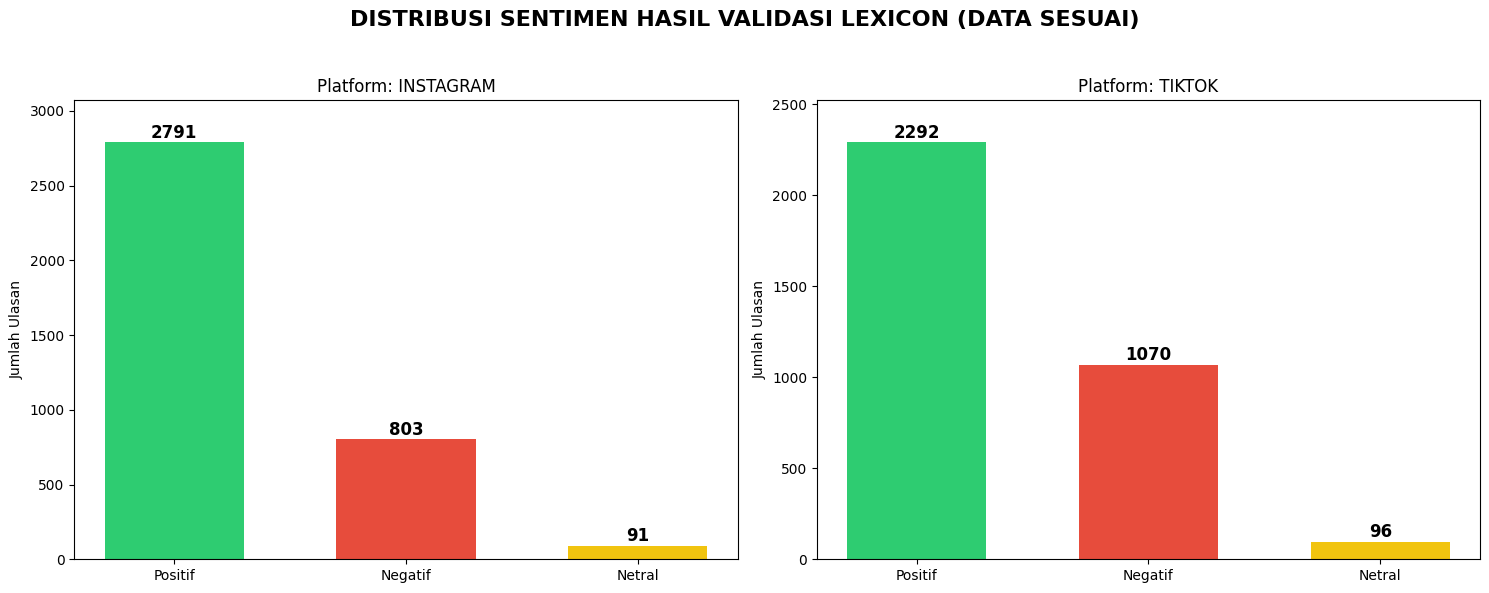

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# 1. Definisi Kamus Lexicon (Berdasarkan Konten)
# ==========================================
lexicon_positive = {
    'bagus', 'baik', 'mantap', 'keren', 'cepat', 'mudah', 'suka', 'puas',
    'mantul', 'hebat', 'top', 'oke', 'stabil', 'enak', 'nyaman', 'seru',
    'menarik', 'jernih', 'bantu', 'manfaat', 'lancar', 'ringan', 'senang',
    'aman', 'canggih', 'lengkap', 'terbaik', 'indah', 'favorit', 'lucu',
    'menghibur', 'asyik', 'cocok', 'paham', 'untung', 'berhasil', 'rekomendasi',
    'terimakasih', 'makasih', 'cinta', 'love', 'setuju', 'mending', 'hd',
    'nice', 'best', 'moga', 'terima', 'hibur', 'praktis', 'tarik', 'jaya'
}

lexicon_negative = {
    'buruk', 'jelek', 'lemot', 'lambat', 'error', 'kecewa', 'susah', 'blok',
    'payah', 'parah', 'crash', 'lag', 'benci', 'ribet', 'kesal', 'lelah',
    'eror', 'macet', 'masalah', 'hapus', 'hilang', 'rugi', 'bosan',
    'lelet', 'lamban', 'stuck', 'bug', 'berat', 'boros', 'penuh', 'tutup',
    'forceclose', 'keluar', 'blokir', 'suspensi', 'suspend', 'sulit', 'aneh',
    'sampah', 'burik', 'kaku', 'marah', 'nyebelin', 'kejam', 'pelit',
    'mengecewakan', 'rendah', 'hancur', 'kurang', 'nyesel', 'bosen', 'leg',
    'malah', 'langgar', 'kena', 'spam', 'bot', 'curiga', 'sepihak', 'lot',
    'iklan', 'sandi', 'ulang', 'kait', 'berhenti', 'tolak', 'sulit', 'balas'
}

# ==========================================
# 2. Fungsi Hybrid Sentiment (Lexicon + Rating)
# ==========================================
def hybrid_lexicon_sentiment(row):
    text = str(row['stemmed']).lower()
    score = row['score']

    # Jika teks kosong atau hanya emoji
    if pd.isna(row['stemmed']) or text.strip() == "" or text == 'nan':
        if score >= 4: return 'positif'
        elif score <= 2: return 'negatif'
        else: return 'netral'

    pos, neg = 0, 0
    words = text.split()
    for word in words:
        if word in lexicon_positive:
            pos += 1
        if word in lexicon_negative:
            neg += 1

    if pos > neg:
        return 'positif'
    elif neg > pos:
        return 'negatif'
    else:
        # Jika Lexicon Netral, gunakan Score Rating sebagai penentu
        if score >= 4: return 'positif'
        elif score <= 2: return 'negatif'
        else: return 'netral'

# ==========================================
# 3. Proses File & Filtering Data
# ==========================================
files = [
    "ulasan_instagram_preprocessing_labeled.csv",
    "ulasan_tiktok_preprocessing_labeled.csv"
]

stats_valid = {}

for file in files:
    try:
        # Load Data
        df = pd.read_csv(file)

        # 1. Jalankan Sentiment Lexicon
        df['sentiment_lexicon'] = df.apply(hybrid_lexicon_sentiment, axis=1)

        # 2. Tandai validasi (Cek kesesuaian)
        df['validasi'] = df.apply(
            lambda x: 'sesuai' if str(x['sentiment']).lower() == str(x['sentiment_lexicon']).lower() else 'tidak sesuai',
            axis=1
        )

        # 3. HAPUS DATA YANG TIDAK SESUAI
        # Menyimpan hanya data yang sinkron antara label manual dan lexicon
        df_clean = df[df['validasi'] == 'sesuai'].copy()

        # Simpan file hasil pembersihan
        output_name = file.replace(".csv", "_lexicon_final_cleaned.csv")
        df_clean.to_csv(output_name, index=False)

        # Hitung statistik dari data yang sudah valid
        jml_final = df_clean['sentiment'].value_counts().reindex(['positif', 'negatif', 'netral'], fill_value=0)
        stats_valid[file] = jml_final

        # Print info pembersihan
        print(f"--- {file} ---")
        print(f"Data Awal         : {len(df)}")
        print(f"Data Dihapus      : {len(df) - len(df_clean)}")
        print(f"Data Valid (Tetap): {len(df_clean)}")
        print(f"Akurasi Awal      : {(len(df_clean)/len(df)*100):.2f}%\n")

    except Exception as e:
        print(f"Gagal memproses {file}: {e}")

# ==========================================
# 4. Visualisasi Data Terverifikasi (Hasil Akhir)
# ==========================================
labels = ['Positif', 'Negatif', 'Netral']
x = np.arange(len(labels))
width = 0.6

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("DISTRIBUSI SENTIMEN HASIL VALIDASI LEXICON (DATA SESUAI)", fontsize=16, fontweight='bold')

for i, file in enumerate(files):
    jml = stats_valid[file]
    ax = axes[i]

    # Karena data sudah sesuai, kita hanya perlu menampilkan satu bar per kategori
    bars = ax.bar(labels, jml, width, color=['#2ecc71', '#e74c3c', '#f1c40f'])

    platform_name = "INSTAGRAM" if "instagram" in file else "TIKTOK"
    ax.set_title(f"Platform: {platform_name}")
    ax.set_ylabel("Jumlah Ulasan")
    ax.set_ylim(0, max(jml) + (max(jml)*0.1)) # Memberi ruang untuk teks di atas bar

    # Tambahkan Label Angka di atas Bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 3,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

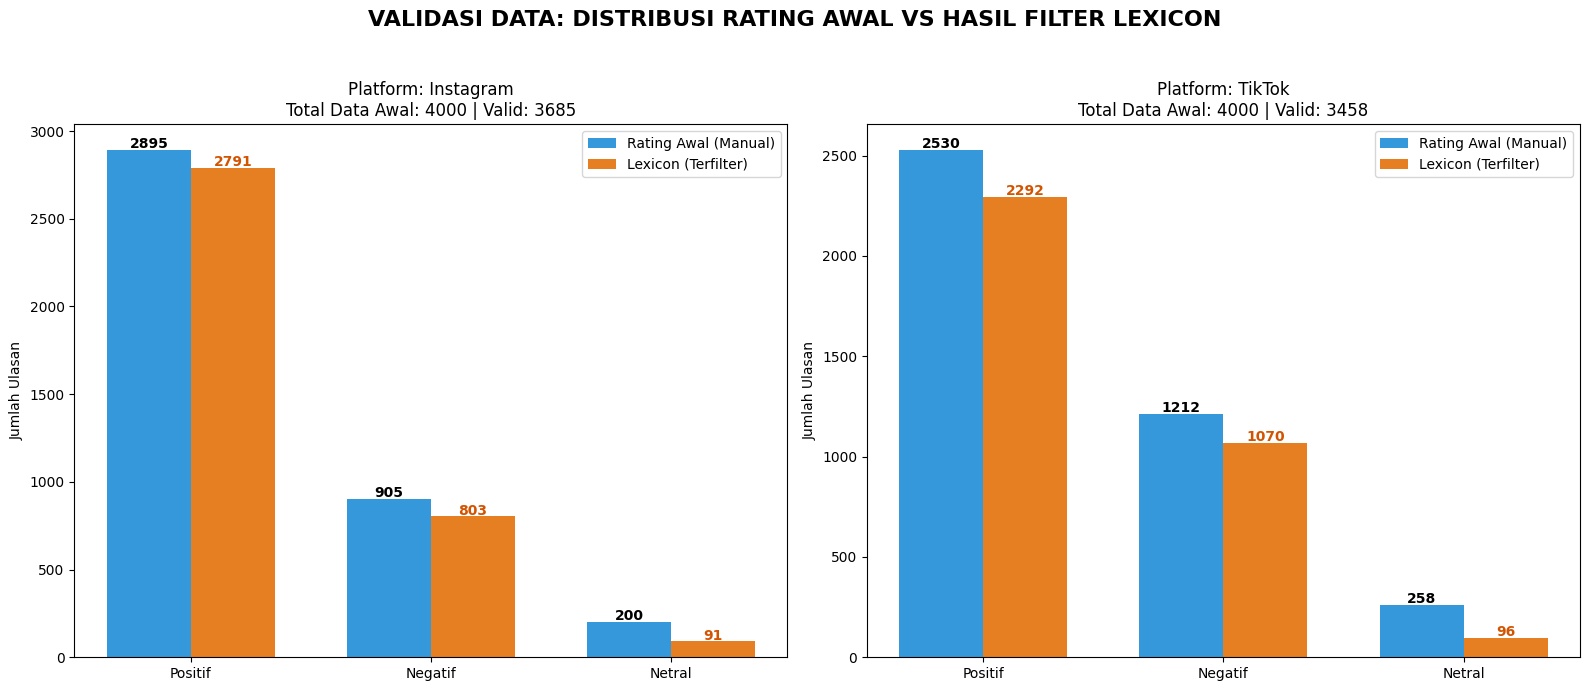

In [35]:
# ==========================================
# 5. VISUALISASI PERBANDINGAN RATING AWAL VS HASIL FILTER
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi Label
labels = ['Positif', 'Negatif', 'Netral']
sentiment_order = ['positif', 'negatif', 'netral']
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("VALIDASI DATA: DISTRIBUSI RATING AWAL VS HASIL FILTER LEXICON", fontsize=16, fontweight='bold')

# Pastikan path file sesuai dengan yang ada di folder Colab Anda
platforms = {
    'Instagram': {
        'awal': "ulasan_instagram_preprocessing_labeled.csv",
        'filter': "ulasan_instagram_preprocessing_labeled_lexicon_final_cleaned.csv"
    },
    'TikTok': {
        'awal': "ulasan_tiktok_preprocessing_labeled.csv",
        'filter': "ulasan_tiktok_preprocessing_labeled_lexicon_final_cleaned.csv"
    }
}

for idx, (platform, paths) in enumerate(platforms.items()):
    try:
        # Load Data Awal (Rating) dan Data Filter (Lexicon)
        df_awal = pd.read_csv(paths['awal'])
        df_filter = pd.read_csv(paths['filter'])

        # --- PERHITUNGAN DATA ---
        # Menghitung distribusi rating awal (Pilar Biru)
        jml_awal = df_awal['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).tolist()

        # Menghitung distribusi lexicon setelah filter (Pilar Oranye)
        jml_filter = df_filter['sentiment_lexicon'].value_counts().reindex(sentiment_order, fill_value=0).tolist()

        # Visualisasi
        ax = axes[idx]
        bar1 = ax.bar(x - width/2, jml_awal, width, label='Rating Awal (Manual)', color='#3498db')
        bar2 = ax.bar(x + width/2, jml_filter, width, label='Lexicon (Terfilter)', color='#e67e22')

        ax.set_title(f"Platform: {platform}\nTotal Data Awal: {sum(jml_awal)} | Valid: {sum(jml_filter)}")
        ax.set_ylabel("Jumlah Ulasan")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()

        # Menampilkan angka di atas setiap bar agar perhitungan data terlihat jelas
        for i, v in enumerate(jml_awal):
            ax.text(i - width/2, v + 10, str(v), ha='center', fontweight='bold', fontsize=10)
        for i, v in enumerate(jml_filter):
            ax.text(i + width/2, v + 10, str(v), ha='center', fontweight='bold', color='#d35400', fontsize=10)

    except Exception as e:
        print(f"Error pada platform {platform}: {e}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

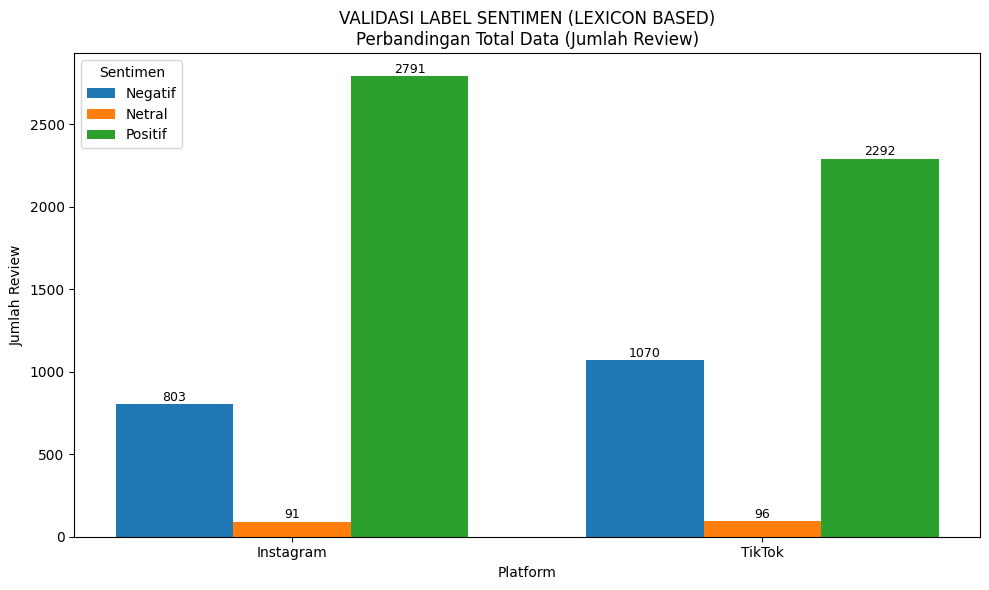

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load data
# =========================
df_instagram = pd.read_csv("ulasan_instagram_preprocessing_labeled_lexicon_final_cleaned.csv")
df_tiktok = pd.read_csv("ulasan_tiktok_preprocessing_labeled_lexicon_final_cleaned.csv")

# =========================
# Hitung jumlah sentimen (LEXICON)
# =========================
def hitung_jumlah_lexicon(df):
    return df['sentiment_lexicon'].value_counts().reindex(
        ['negatif', 'netral', 'positif'], fill_value=0
    )

ig = hitung_jumlah_lexicon(df_instagram)
tt = hitung_jumlah_lexicon(df_tiktok)

labels = ['Negatif', 'Netral', 'Positif']
x = np.arange(2)  # Instagram, TikTok
width = 0.25

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))

plt.bar(x - width, [ig[0], tt[0]], width, label='Negatif')
plt.bar(x,         [ig[1], tt[1]], width, label='Netral')
plt.bar(x + width, [ig[2], tt[2]], width, label='Positif')

plt.xticks(x, ['Instagram', 'TikTok'])
plt.ylabel("Jumlah Review")
plt.xlabel("Platform")
plt.title("VALIDASI LABEL SENTIMEN (LEXICON BASED)\nPerbandingan Total Data (Jumlah Review)")
plt.legend(title="Sentimen")

# =========================
# Tampilkan angka di atas bar
# =========================
for i, data in enumerate([ig, tt]):
    for j, v in enumerate(data):
        xpos = i + (j - 1) * width
        plt.text(xpos, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

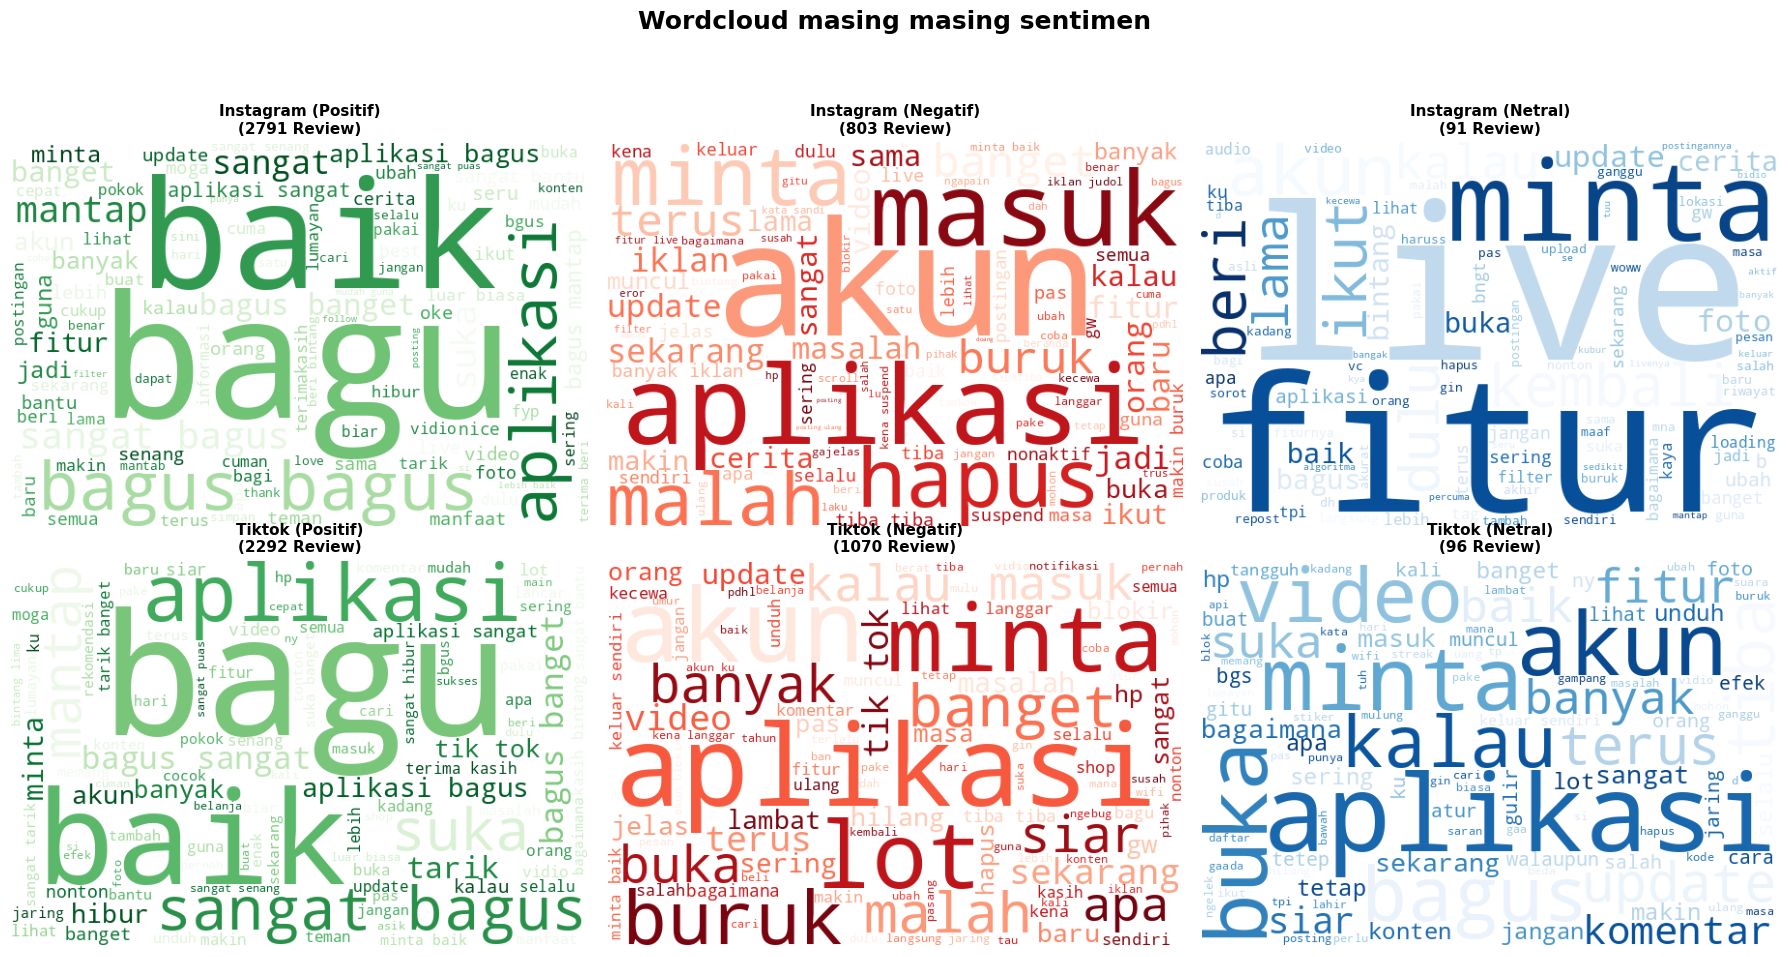

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =========================
# Load data
# =========================
df_instagram = pd.read_csv("ulasan_instagram_preprocessing_labeled_lexicon_final_cleaned.csv")
df_tiktok = pd.read_csv("ulasan_tiktok_preprocessing_labeled_lexicon_final_cleaned.csv")

# =========================
# Fungsi Wordcloud per sentimen
# =========================
def buat_wordcloud(df, sentiment, color):
    text = " ".join(
        df[df['sentiment_lexicon'] == sentiment]['stemmed']
        .dropna()
        .astype(str)
    )

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=color,
        max_words=100
    ).generate(text)

    return wc, len(df[df['sentiment_lexicon'] == sentiment])

# =========================
# Setup Figure (2x3)
# =========================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Wordcloud masing masing sentimen", fontsize=18, fontweight='bold')

sentiments = [
    ('positif', 'Greens'),
    ('negatif', 'Reds'),
    ('netral',  'Blues')
]

# =========================
# Instagram
# =========================
for i, (sent, color) in enumerate(sentiments):
    wc, total = buat_wordcloud(df_instagram, sent, color)
    axes[0, i].imshow(wc)
    axes[0, i].axis('off')
    axes[0, i].set_title(
        f"Instagram ({sent.capitalize()})\n({total} Review)",
        fontsize=11,
        fontweight='bold'
    )

# =========================
# TikTok
# =========================
for i, (sent, color) in enumerate(sentiments):
    wc, total = buat_wordcloud(df_tiktok, sent, color)
    axes[1, i].imshow(wc)
    axes[1, i].axis('off')
    axes[1, i].set_title(
        f"Tiktok ({sent.capitalize()})\n({total} Review)",
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

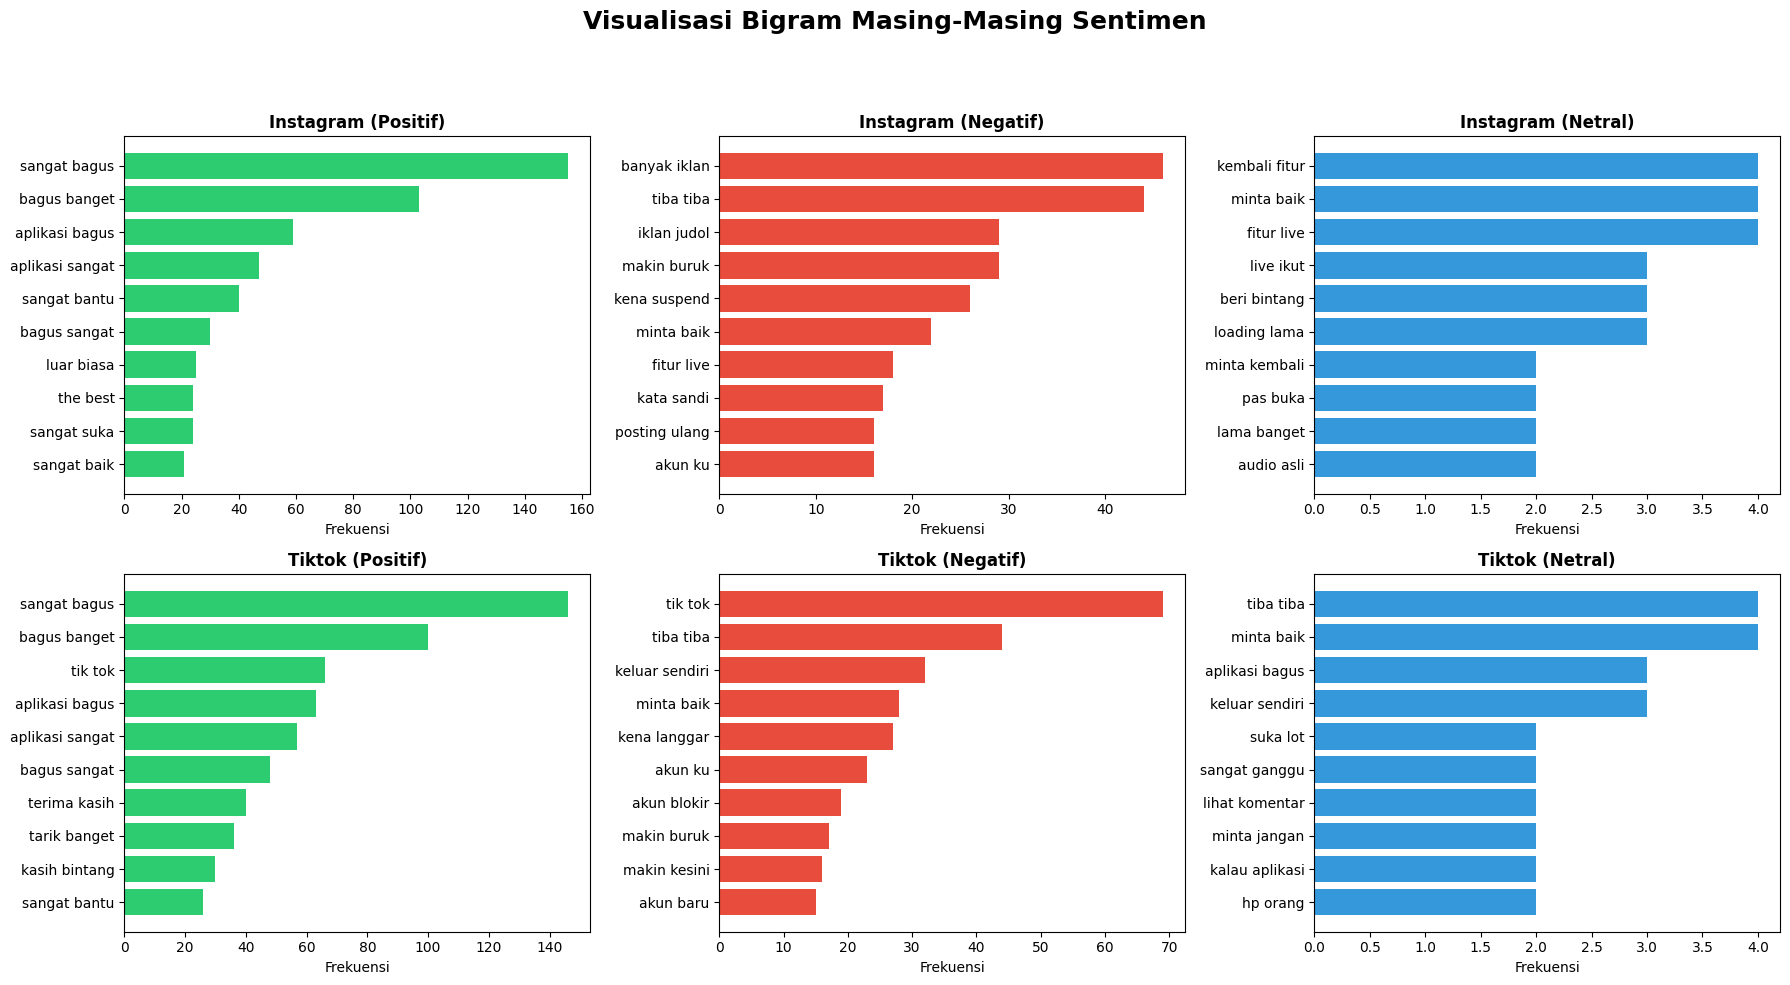

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# Load data
# =========================
df_instagram = pd.read_csv("ulasan_instagram_preprocessing_labeled_lexicon_final_cleaned.csv")
df_tiktok = pd.read_csv("ulasan_tiktok_preprocessing_labeled_lexicon_final_cleaned.csv")

# =========================
# Fungsi ambil top bigram
# =========================
def get_top_bigram(df, sentiment, top_n=10):
    data = df[df['sentiment_lexicon'] == sentiment]['stemmed'].dropna().astype(str)

    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        max_features=top_n
    )
    X = vectorizer.fit_transform(data)

    freq = X.sum(axis=0).A1
    bigrams = vectorizer.get_feature_names_out()

    result = pd.DataFrame({
        'bigram': bigrams,
        'freq': freq
    }).sort_values(by='freq', ascending=True)

    return result

# =========================
# Setup figure
# =========================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Visualisasi Bigram Masing-Masing Sentimen", fontsize=18, fontweight='bold')

sentiments = ['positif', 'negatif', 'netral']
colors = {
    'positif': '#2ecc71',
    'negatif': '#e74c3c',
    'netral':  '#3498db'
}

# =========================
# Instagram (GFX Pro)
# =========================
for i, sent in enumerate(sentiments):
    bigram_df = get_top_bigram(df_instagram, sent)

    axes[0, i].barh(bigram_df['bigram'], bigram_df['freq'], color=colors[sent])
    axes[0, i].set_title(f"Instagram ({sent.capitalize()})", fontweight='bold')
    axes[0, i].set_xlabel("Frekuensi")

# =========================
# TikTok (Game Booster Plus)
# =========================
for i, sent in enumerate(sentiments):
    bigram_df = get_top_bigram(df_tiktok, sent)

    axes[1, i].barh(bigram_df['bigram'], bigram_df['freq'], color=colors[sent])
    axes[1, i].set_title(f"Tiktok ({sent.capitalize()})", fontweight='bold')
    axes[1, i].set_xlabel("Frekuensi")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


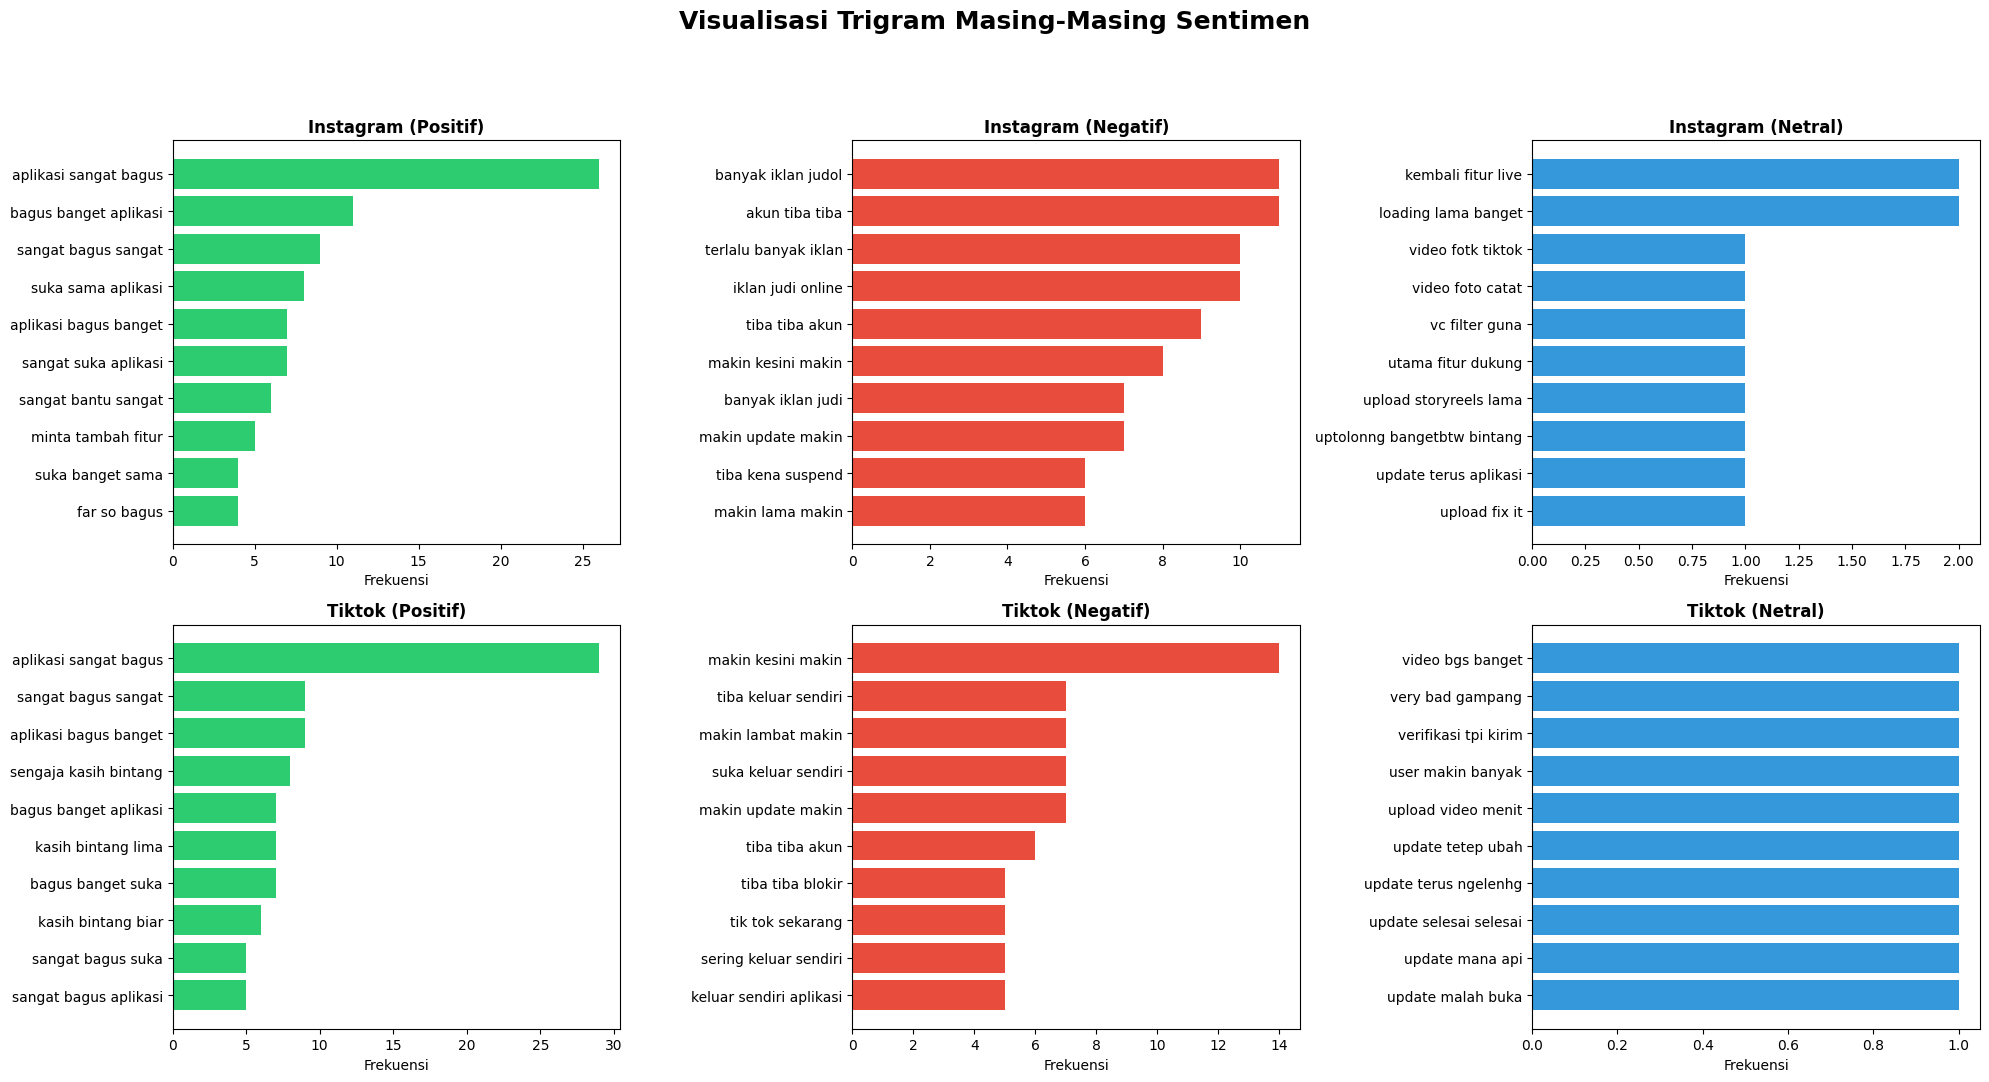

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# Load data
# =========================
df_instagram = pd.read_csv("ulasan_instagram_preprocessing_labeled_lexicon_final_cleaned.csv")
df_tiktok = pd.read_csv("ulasan_tiktok_preprocessing_labeled_lexicon_final_cleaned.csv")

# =========================
# Fungsi ambil top trigram
# =========================
def get_top_trigram(df, sentiment, top_n=10):
    data = df[df['sentiment_lexicon'] == sentiment]['stemmed'].dropna().astype(str)

    vectorizer = CountVectorizer(
        ngram_range=(3, 3),
        max_features=top_n
    )
    X = vectorizer.fit_transform(data)

    freq = X.sum(axis=0).A1
    trigrams = vectorizer.get_feature_names_out()

    result = pd.DataFrame({
        'trigram': trigrams,
        'freq': freq
    }).sort_values(by='freq', ascending=True)

    return result

# =========================
# Setup figure
# =========================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(
    "Visualisasi Trigram Masing-Masing Sentimen",
    fontsize=18,
    fontweight='bold'
)

sentiments = ['positif', 'negatif', 'netral']
colors = {
    'positif': '#2ecc71',
    'negatif': '#e74c3c',
    'netral':  '#3498db'
}

# =========================
# Instagram (GFX Pro)
# =========================
for i, sent in enumerate(sentiments):
    trigram_df = get_top_trigram(df_instagram, sent)

    axes[0, i].barh(
        trigram_df['trigram'],
        trigram_df['freq'],
        color=colors[sent]
    )
    axes[0, i].set_title(
        f"Instagram ({sent.capitalize()})",
        fontweight='bold'
    )
    axes[0, i].set_xlabel("Frekuensi")

# =========================
# TikTok (Game Booster Plus)
# =========================
for i, sent in enumerate(sentiments):
    trigram_df = get_top_trigram(df_tiktok, sent)

    axes[1, i].barh(
        trigram_df['trigram'],
        trigram_df['freq'],
        color=colors[sent]
    )
    axes[1, i].set_title(
        f"Tiktok ({sent.capitalize()})",
        fontweight='bold'
    )
    axes[1, i].set_xlabel("Frekuensi")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
